# Imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import floor
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Loading and Cleaning Data

**Notes:** Null values (total_bedrooms) and categorical data (ocean_proximity) must be handled. Null values can be fixed now but would result in data leakage. The missing values would be based on all the data in the set. But the test data must remain untouched. Categorical data will also be handled at a later step during preprocessing

In [2]:
# Load csv file as dataframe
housing_df = pd.read_csv("Data/housing.csv")

# Inspect the data and check data types
display(housing_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

### Simple EDA
Plotting median_house_value on a histogram to check distribution

**Notes:** The median house values appear skewed left with outliers in the near 500k region

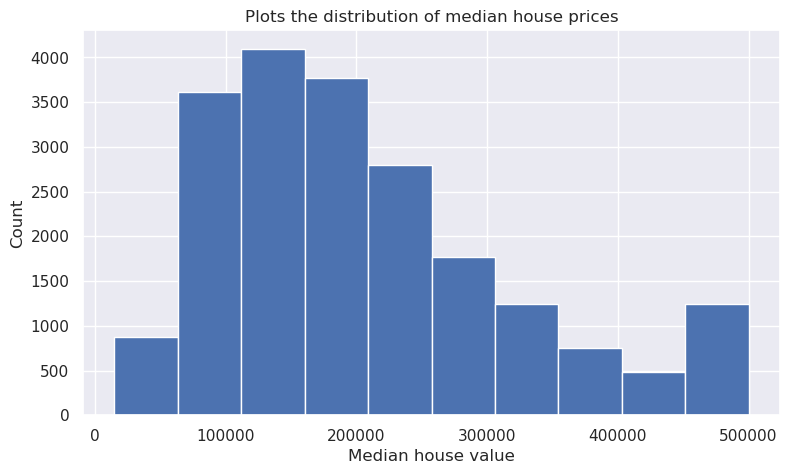

In [4]:
# Create a histogram to check distribution of median_house_value
plt.figure(figsize=(9, 5))
plt.hist(housing_df["median_house_value"])
plt.xlabel("Median house value")
plt.ylabel("Count")
plt.title("Plots the distribution of median house prices")
plt.show()

Plotting a heatmap of the columns except ocean_proximity to check for correlation

**Notes:**
1. The most correlating columns are total_rooms, total_bedrooms, population and households which is expected. More people requires for households, total_rooms or total_bedrooms.
2. Median_house_value is relatively correlated to the median_income which is also expected. More income makes it possible to get a more expensive house.

**Idea:** Perhaps it is possible to drop the "irrelevant" columns to speed up calculations and training

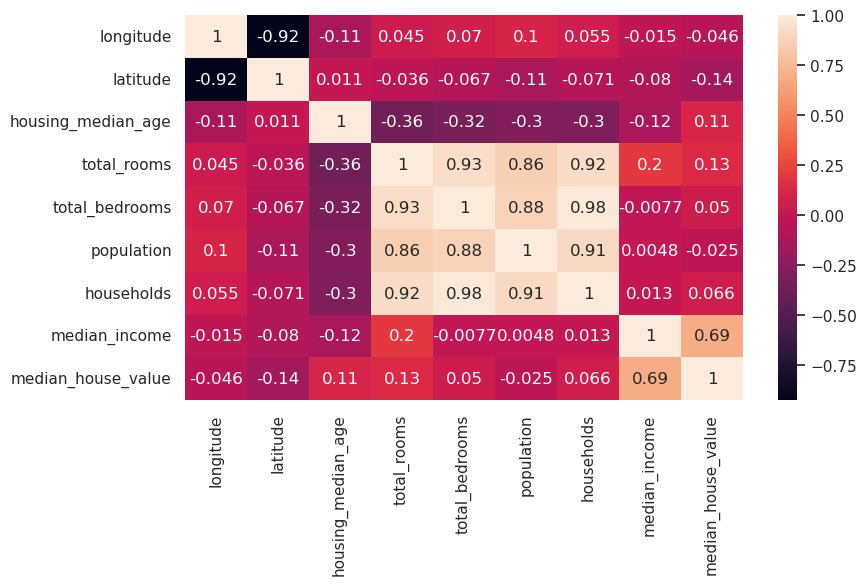

In [5]:
df_drop_ocean_prox = housing_df.copy()

matrix = df_drop_ocean_prox.drop("ocean_proximity", axis=1).corr()

plt.figure(figsize=(9, 5))
sns.heatmap(matrix, annot=True)
plt.show()

### Testing to assign numerical values to ocean_proximity. The closer you are to water the higher the number.
1. Island = 5
2. Near ocean 4
3. Near bay = 3
4. &gt; 1km = 2
5. Inland = 1

**Notes:** It is very hard to assign a weight on ocean_proximity manually. This model assumes a decreasing weight in the order of island, near ocean, near bay, >1h ocean and inland. It does appear from this model that ocean_proximity is somewhat correlated to the median_house_value but not substantially.


In [6]:
df_numeric_ocean_prox = housing_df.copy()

df_numeric_ocean_prox["ocean_proximity"].replace("ISLAND", 5, inplace=True)
df_numeric_ocean_prox["ocean_proximity"].replace("NEAR OCEAN", 4, inplace=True)
df_numeric_ocean_prox["ocean_proximity"].replace("NEAR BAY", 3, inplace=True)
df_numeric_ocean_prox["ocean_proximity"].replace("<1H OCEAN", 2, inplace=True)
df_numeric_ocean_prox["ocean_proximity"].replace("INLAND", 1, inplace=True)

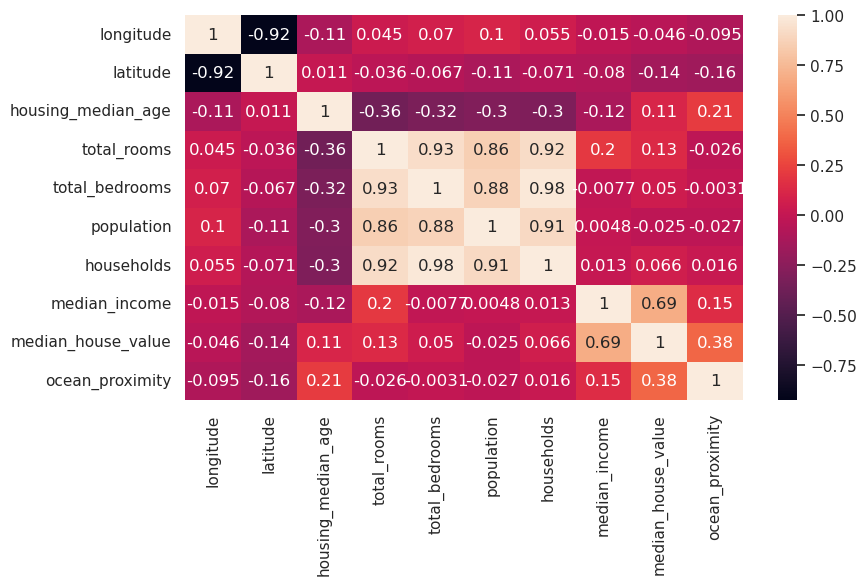

In [7]:
matrix = df_numeric_ocean_prox.corr()

plt.figure(figsize=(9, 5))
sns.heatmap(matrix, annot=True)
plt.show()

# Split and Preprocessing

In [ ]:
# Check the average number of bedrooms per household and round down to nearest integer
avg_bedrooms_per_household = housing_df["total_bedrooms"].sum() / housing_df["households"].sum()
bedrooms_floor = floor(avg_bedrooms_per_household)
print("Average bedrooms per household: ", avg_bedrooms_per_household, "\nBedrooms rounded down: ", bedrooms_floor)

# Fill null with bedrooms_floor
housing_df["total_bedrooms"] = housing_df["total_bedrooms"].fillna(avg_bedrooms_per_household)

housing_df.describe()